# Why Did This Delivery Forecast Jump? Separating Changed Conditions from a Model Update

At 09:00, ETA model v1 predicts **28.5 minutes remaining** for delivery **DEL-042**. Fifteen minutes later, model v2 predicts **54.8 minutes remaining** for the same delivery, even though the courier is now 2 km closer! Congestion worsened, three stops were added, rain began, and by 09:15 the platform's new model was active.

This raises an attribution question: **How much of the 26.3-minute increase came from each changed condition, and how much came from the model update?**

We will use `dowhy.gcm.unit_change` to build an order-independent attribution that exactly reconstructs the forecast change, first for DEL-042 and then across a batch of deliveries.

<style>
.jp-RenderedHTMLCommon table,
.jp-OutputArea-output table,
.nboutput .output_area table {
    margin-left: auto !important;
    margin-right: auto !important;
}
.jp-RenderedImage img,
.jp-OutputArea-output img,
.nboutput .output_area img {
    display: block;
    margin-left: auto !important;
    margin-right: auto !important;
}
.unit-change-diagram {
    display: flex;
    justify-content: center;
    margin: 1rem 0;
}
.unit-change-diagram pre {
    display: inline-block;
    margin: 0;
    text-align: left;
}
</style>

## What exactly are we explaining?

DEL-042 is one statistical unit observed in two contexts. DoWhy calls the earlier context the **background** and the later context the **foreground**:

| | Background | Foreground |
|:---|:---:|:---:|
| Snapshot | 09:00 | 09:15 |
| Delivery state | <i>x</i><sub>09:00</sub> | <i>x</i><sub>09:15</sub> |
| Prediction mechanism | <i>f</i><sub>v1</sub> | <i>f</i><sub>v2</sub> |
| Forecast | <i>f</i><sub>v1</sub>(<i>x</i><sub>09:00</sub>) = 28.5 | <i>f</i><sub>v2</sub>(<i>x</i><sub>09:15</sub>) = 54.8 |

Two things changed between these endpoints: the input vector $x$ **and** the prediction function $f$. Their endpoint contrast is $f_{v2}(x_{09:15}) - f_{v1}(x_{09:00}) = 26.3$ minutes. Subtraction gives the total, but it cannot tell us how much to assign to remaining distance, congestion, stops, rain, or the model update. We want five contributions that sum back to 26.3 minutes exactly.

Typical feature-attribution explanations hold the prediction mechanism fixed. Here, replacing the mechanism is itself one of the possible explanations. This is the setting studied in [*Explaining the root causes of unit-level changes*](https://arxiv.org/abs/2206.12986) by Budhathoki, Michailidis, and Janzing, which uses counterfactual Shapley values to account for changes in both inputs and the function mapping them to an output.

The target here is the change in the platform's **forecast**, not the effect of intervening on traffic or weather on actual delivery time.

In [1]:
import numpy as np
import pandas as pd

import dowhy
from dowhy import gcm

SEED = 2026
dowhy.enable_notebook_rendering()
gcm.config.disable_progress_bars()

## 1. Pair the background and foreground delivery states

Both contexts must describe the same unit with the same ordered feature schema. In production, these values would normally come from two logged prediction snapshots. We hand-construct one pair here so every contribution is transparent and exactly checkable; `unit_change` does not require synthetic data.

Between 09:00 and 09:15, the courier travels 2 km, but congestion increases by 12 minutes, three stops are added, and rain intensity rises from 0 to 0.8.

In [2]:
FEATURES = ["remaining_km", "congestion_minutes", "stops_ahead", "rain_intensity"]
FEATURE_LABELS = {
    "remaining_km": "Remaining distance",
    "congestion_minutes": "Congestion",
    "stops_ahead": "Stops ahead",
    "rain_intensity": "Rain intensity",
    "f": "ETA mechanism",
}

delivery_id = pd.Index(["DEL-042"], name="delivery_id")
snapshot_0900 = pd.DataFrame([[6.5, 4.0, 1.0, 0.0]], columns=FEATURES, index=delivery_id)
snapshot_0915 = pd.DataFrame([[4.5, 16.0, 4.0, 0.8]], columns=FEATURES, index=delivery_id)

### Specify the two prediction mechanisms

To focus on attribution rather than model estimation, we specify two fixed, known linear mechanisms. Version 2 lowers the baseline and distance weight while responding more strongly to congestion, stops, and rain:

$$
f_{v1}(x) = 8 + 2.2d + 0.8c + 3.0s + 6.0r
$$

$$
f_{v2}(x) = 5 + 2.0d + 1.1c + 3.8s + 10.0r.
$$

Here $d$ is remaining distance, $c$ is expected congestion delay, $s$ is the number of stops ahead, and $r$ is rain intensity. The same `unit_change` API also accepts nonlinear DoWhy `PredictionModel` implementations.

In [3]:
COEFFICIENTS_V1 = np.array([2.2, 0.8, 3.0, 6.0])
COEFFICIENTS_V2 = np.array([2.0, 1.1, 3.8, 10.0])
INTERCEPT_V1 = 8.0
INTERCEPT_V2 = 5.0

eta_v1 = gcm.ml.create_linear_regressor_with_given_parameters(COEFFICIENTS_V1, INTERCEPT_V1)
eta_v2 = gcm.ml.create_linear_regressor_with_given_parameters(COEFFICIENTS_V2, INTERCEPT_V2)

In [4]:
eta_0900 = eta_v1.predict(snapshot_0900[FEATURES].to_numpy()).ravel()
eta_0915 = eta_v2.predict(snapshot_0915[FEATURES].to_numpy()).ravel()
eta_delta = eta_0915 - eta_0900

paired_snapshots = pd.concat(
    [snapshot_0900, snapshot_0915],
    keys=["09:00", "09:15"],
    names=["Snapshot"],
)
paired_snapshots["ETA model"] = ["v1", "v2"]
paired_snapshots["Forecast (minutes remaining)"] = [eta_0900[0], eta_0915[0]]
paired_snapshots.rename(columns={name: FEATURE_LABELS[name] for name in FEATURES}).round(1)

,,Remaining distance,Congestion,Stops ahead,Rain intensity,ETA model,Forecast (minutes remaining)
Snapshot,delivery_id,,,,,,
09:00,DEL-042,6.5,4.0,1.0,0.0,v1,28.5
09:15,DEL-042,4.5,16.0,4.0,0.8,v2,54.8


## 2. Why ordinary subtraction is not enough

Subtracting the endpoint forecasts gives 26.3 minutes, but it does not allocate that difference. We could first substitute the 09:15 delivery conditions into v1 and then switch to v2. Or we could switch models at the 09:00 conditions and only then substitute the new conditions:

<div class="unit-change-diagram">
<pre>
                        change conditions
        f_v1(x_09:00) --------------------> f_v1(x_09:15)
             |                                  |
switch to v2 |                                  | switch to v2
             v                                  v
        f_v2(x_09:00) --------------------> f_v2(x_09:15)
                        change conditions
</pre>
</div>

Because v1 and v2 weight the inputs differently, the two paths assign different amounts to changed conditions and the model update. Both start at 28.5 and end at 54.8; the endpoint comparison does not privilege either path.

In [5]:
def predict_one(mechanism, row):
    return mechanism.predict(row[FEATURES].to_numpy()).item()


eta_v1_at_0900 = predict_one(eta_v1, snapshot_0900)
eta_v1_at_0915 = predict_one(eta_v1, snapshot_0915)
eta_v2_at_0900 = predict_one(eta_v2, snapshot_0900)
eta_v2_at_0915 = predict_one(eta_v2, snapshot_0915)

sequential_accounting = pd.DataFrame(
    {
        "Changed delivery conditions": [
            eta_v1_at_0915 - eta_v1_at_0900,
            eta_v2_at_0915 - eta_v2_at_0900,
        ],
        "Changed ETA mechanism": [
            eta_v2_at_0915 - eta_v1_at_0915,
            eta_v2_at_0900 - eta_v1_at_0900,
        ],
    },
    index=["Conditions first", "Mechanism first"],
)
sequential_accounting["Total change"] = sequential_accounting.sum(axis=1)

## 3. Replace path dependence with Shapley accounting

The two paths show why we need an allocation rule. If delivery conditions change first, conditions receive **19.0 minutes** and the model update **7.3**. If the model changes first, conditions receive **28.6 minutes** and the update **−2.3**.

Shapley accounting does not choose one path. It averages a contributor's marginal effect across every possible replacement order. Temporarily treating all delivery conditions as one contributor gives

$$
\phi_{conditions} = \frac{19.0 + 28.6}{2} = 23.8,
\qquad
\phi_{model} = \frac{7.3 - 2.3}{2} = 2.5.
$$

`gcm.unit_change` performs the finer calculation directly. Its five players are remaining distance, congestion, stops, rain, and the model itself. Imagine replacing them from old to new one at a time: a player's increment can depend on what has already been replaced, so the exact Shapley value averages that increment conceptually over all $5! = 120$ orders.

We request exact Shapley values and one worker to keep the example serial. `unit_change` pairs rows by position and returns a fresh index, so we validate the pairing and restore the delivery ID explicitly. Its mechanism contribution is named `f`.

In [6]:
shapley_config = gcm.shapley.ShapleyConfig(
    approximation_method=gcm.shapley.ShapleyApproximationMethods.EXACT,
    n_jobs=1,
)

assert snapshot_0900.index.equals(snapshot_0915.index), "Snapshot rows must be paired in the same order."

attributions = gcm.unit_change(
    background_df=snapshot_0900,
    foreground_df=snapshot_0915,
    input_column_names=FEATURES,
    background_mechanism=eta_v1,
    foreground_mechanism=eta_v2,
    shapley_config=shapley_config,
)
# unit_change returns a fresh index; restore the validated delivery ID.
attributions.index = snapshot_0900.index

In [7]:
expected_attributions = np.array([-4.2, 11.4, 10.2, 6.4, 2.5])
np.testing.assert_allclose(attributions.loc["DEL-042"].to_numpy(), expected_attributions, atol=1e-10)
np.testing.assert_allclose(attributions.sum(axis=1).to_numpy(), eta_delta, atol=1e-10)

In [8]:
accounting_comparison = sequential_accounting.drop(columns="Total change").rename(
    columns={
        "Changed delivery conditions": "Delivery conditions",
        "Changed ETA mechanism": "Model update",
    }
)
accounting_comparison.loc["DoWhy / Shapley"] = [
    attributions[FEATURES].sum(axis=1).iloc[0],
    attributions["f"].iloc[0],
]
accounting_comparison["Total"] = accounting_comparison.sum(axis=1)
accounting_comparison.index.name = None
accounting_comparison.round(1)

,Delivery conditions,Model update,Total
Conditions first,19.0,7.3,26.3
Mechanism first,28.6,-2.3,26.3
DoWhy / Shapley,23.8,2.5,26.3


The grouped average above is intuition, not an extra grouping step inside `unit_change`. When both the background and foreground mechanisms are linear and additive, the four input attributions sum to **23.8 minutes**, and the attribution to input $j$ is

$$
\phi_j = \frac{\beta_{v1,j} + \beta_{v2,j}}{2}(x_{09:15,j} - x_{09:00,j}),
$$

while the mechanism contribution is

$$
\phi_f = (\beta_{v2} - \beta_{v1})^\top \frac{x_{09:00} + x_{09:15}}{2} + (b_{v2} - b_{v1}).
$$

These equations provide an analytical check for this example. The `unit_change` call above uses the general counterfactual implementation, which also works with nonlinear DoWhy prediction mechanisms.

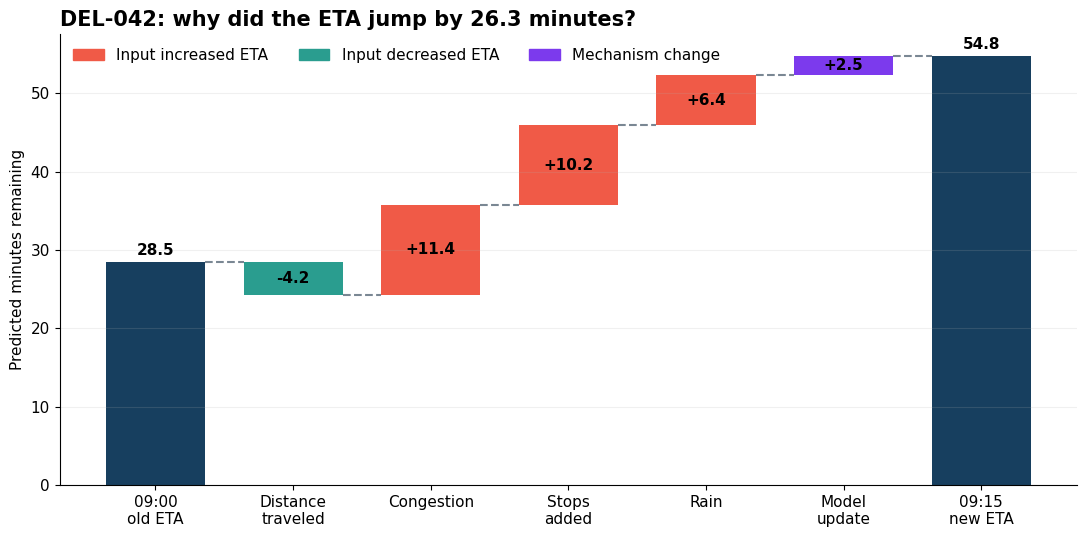

In [9]:
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Patch

plt.rcParams.update(
    {
        "figure.figsize": (10, 5.5),
        "font.size": 11,
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": False,
        "grid.alpha": 0.18,
    }
)


def plot_attribution_waterfall(start_value, contributions, end_value):
    labels = [
        "09:00\nold ETA",
        "Distance\ntraveled",
        "Congestion",
        "Stops\nadded",
        "Rain",
        "Model\nupdate",
        "09:15\nnew ETA",
    ]
    values = contributions.to_numpy()
    cumulative = np.r_[start_value, start_value + np.cumsum(values)]
    colors = [
        "#7C3AED" if name == "f" else "#F05A47" if value > 0 else "#2A9D8F"
        for name, value in zip(contributions.index, values)
    ]

    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.bar(0, start_value, color="#173F5F", width=0.72)

    for position, (value, color) in enumerate(zip(values, colors), start=1):
        previous = cumulative[position - 1]
        bottom = min(previous, previous + value)
        ax.plot([position - 0.64, position - 0.36], [previous, previous], color="#7A8793", ls="--")
        ax.bar(position, abs(value), bottom=bottom, color=color, width=0.72)
        ax.text(
            position,
            bottom + abs(value) / 2,
            f"{value:+.1f}",
            ha="center",
            va="center",
            fontweight="bold",
        )

    final_position = len(values) + 1
    ax.plot(
        [final_position - 0.64, final_position - 0.36],
        [end_value, end_value],
        color="#7A8793",
        ls="--",
    )
    ax.bar(final_position, end_value, color="#173F5F", width=0.72)
    ax.text(0, start_value + 0.9, f"{start_value:.1f}", ha="center", fontweight="bold")
    ax.text(final_position, end_value + 0.9, f"{end_value:.1f}", ha="center", fontweight="bold")

    ax.set_xticks(range(final_position + 1), labels)
    ax.set_ylabel("Predicted minutes remaining")
    ax.set_title("DEL-042: why did the ETA jump by 26.3 minutes?", loc="left", fontsize=15)
    ax.legend(
        handles=[
            Patch(color="#F05A47", label="Input increased ETA"),
            Patch(color="#2A9D8F", label="Input decreased ETA"),
            Patch(color="#7C3AED", label="Mechanism change"),
        ],
        frameon=False,
        ncol=3,
        loc="upper left",
    )
    ax.grid(axis="y", alpha=0.18)
    fig.tight_layout()


plot_attribution_waterfall(eta_0900[0], attributions.loc["DEL-042"], eta_0915[0])

The courier's progress reduced the forecast by 4.2 minutes, but worsening congestion, extra stops, and rain added 28 minutes. The model update received a +2.5-minute attribution for this delivery.

## 4. Same model update, different deliveries

Does one model update receive the same attribution for every delivery? Not necessarily. For this update, changed coefficients interact with each delivery's own before-and-after inputs, so the mechanism contribution varies across units. A batched `unit_change` call reveals where changed conditions and the update reinforce or offset one another, detail that one rollout-wide average would hide.

We construct 120 paired deliveries to demonstrate the batched API and retain DEL-042 as the anchor case. This remains a collection of unit-level explanations, not a distribution-change analysis.

In [10]:
n_deliveries = 120
rng = np.random.default_rng(SEED)
fleet_ids = pd.Index([f"DEL-{number:03d}" for number in range(1, n_deliveries + 1)], name="delivery_id")

fleet_0900 = pd.DataFrame(
    {
        "remaining_km": rng.uniform(1.5, 12.0, n_deliveries),
        "congestion_minutes": np.clip(rng.gamma(2.0, 3.0, n_deliveries), 0, 18),
        "stops_ahead": rng.integers(0, 5, n_deliveries),
        "rain_intensity": rng.beta(1.5, 5.0, n_deliveries),
    },
    index=fleet_ids,
)
fleet_changes = pd.DataFrame(
    {
        "remaining_km": -rng.uniform(0.5, 3.0, n_deliveries),
        "congestion_minutes": rng.normal(2.5, 4.0, n_deliveries),
        "stops_ahead": rng.choice([-1, 0, 1, 2], n_deliveries, p=[0.15, 0.40, 0.30, 0.15]),
        "rain_intensity": rng.normal(0.10, 0.22, n_deliveries),
    },
    index=fleet_ids,
)
fleet_0915 = (fleet_0900 + fleet_changes).clip(
    lower=pd.Series([0.4, 0, 0, 0], index=FEATURES),
    upper=pd.Series([np.inf, 25, 6, 1], index=FEATURES),
    axis=1,
)

fleet_0900.loc["DEL-042"] = snapshot_0900.loc["DEL-042"]
fleet_0915.loc["DEL-042"] = snapshot_0915.loc["DEL-042"]
assert fleet_0900.index.equals(fleet_0915.index), "Snapshot rows must be paired in the same order."

In [11]:
fleet_attributions = gcm.unit_change(
    background_df=fleet_0900,
    foreground_df=fleet_0915,
    input_column_names=FEATURES,
    background_mechanism=eta_v1,
    foreground_mechanism=eta_v2,
    shapley_config=shapley_config,
)
fleet_attributions.index = fleet_0900.index

fleet_eta_0900 = eta_v1.predict(fleet_0900[FEATURES].to_numpy()).ravel()
fleet_eta_0915 = eta_v2.predict(fleet_0915[FEATURES].to_numpy()).ravel()
fleet_eta_delta = pd.Series(fleet_eta_0915 - fleet_eta_0900, index=fleet_0900.index)
np.testing.assert_allclose(fleet_attributions.sum(axis=1), fleet_eta_delta, atol=1e-10)

fleet_results = pd.DataFrame(
    {
        "Changed delivery conditions": fleet_attributions[FEATURES].sum(axis=1),
        "Changed ETA mechanism": fleet_attributions["f"],
        "Total ETA change": fleet_eta_delta,
    }
)

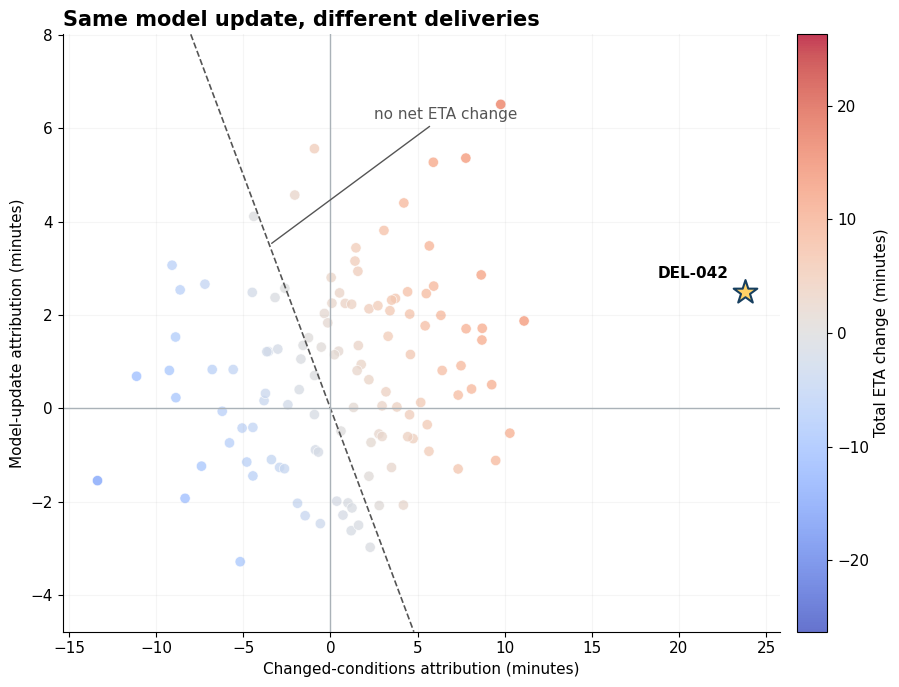

In [12]:
input_change = fleet_results["Changed delivery conditions"]
mechanism_change = fleet_results["Changed ETA mechanism"]
total_change = fleet_results["Total ETA change"]
color_bound = np.max(np.abs(total_change))

fig, ax = plt.subplots(figsize=(9.5, 7))
points = ax.scatter(
    input_change,
    mechanism_change,
    c=total_change,
    cmap="coolwarm",
    norm=TwoSlopeNorm(vmin=-color_bound, vcenter=0, vmax=color_bound),
    s=55,
    alpha=0.78,
    edgecolor="white",
    linewidth=0.5,
)

x_limits = (input_change.min() - 2, input_change.max() + 2)
y_limits = (mechanism_change.min() - 1.5, mechanism_change.max() + 1.5)
boundary_x = np.linspace(max(x_limits[0], -y_limits[1]), min(x_limits[1], -y_limits[0]), 100)
ax.plot(boundary_x, -boundary_x, ls="--", lw=1.2, color="#555555")
ax.axhline(0, color="#AAB2B8", lw=1)
ax.axvline(0, color="#AAB2B8", lw=1)

highlighted = fleet_results.loc["DEL-042"]
ax.scatter(
    highlighted["Changed delivery conditions"],
    highlighted["Changed ETA mechanism"],
    marker="*",
    s=320,
    color="#FFD166",
    edgecolor="#173F5F",
    linewidth=1.5,
    zorder=5,
)
ax.annotate(
    "DEL-042",
    (highlighted["Changed delivery conditions"], highlighted["Changed ETA mechanism"]),
    xytext=(-12, 10),
    textcoords="offset points",
    ha="right",
    fontweight="bold",
)

ax.set(xlim=x_limits, ylim=y_limits)
ax.set_xlabel("Changed-conditions attribution (minutes)")
ax.set_ylabel("Model-update attribution (minutes)")
ax.set_title("Same model update, different deliveries", loc="left", fontsize=15)
ax.annotate(
    "no net ETA change",
    xy=(-3.5, 3.5),
    xytext=(2.5, 6.2),
    arrowprops={"arrowstyle": "-", "color": "#555555"},
    color="#555555",
)
fig.colorbar(points, ax=ax, pad=0.02).set_label("Total ETA change (minutes)")
ax.grid(alpha=0.12)
fig.tight_layout()

Each point is one paired delivery explanation. Its vertical position changes even though every delivery receives the same v1-to-v2 update, because the model change is evaluated at that delivery's inputs. The diagonal marks zero net forecast change; points in the upper-left or lower-right are cases where changed conditions and the model update push in opposite directions.

## Takeaway

When both a unit's inputs and its prediction mechanism change, a two-step explanation depends on whether we replace the inputs or the model first. `gcm.unit_change` treats every changed input and the mechanism as contributors in one Shapley game, producing an order-independent attribution that exactly reconstructs the prediction change.

For DEL-042, that turns a puzzling forecast jump into a concrete account: progress reduced the forecast by 4.2 minutes, worsening conditions added 28.0, and the model update received a 2.5-minute attribution. Across paired batches, the model attribution can differ by unit because the update is evaluated alongside each unit's inputs.